Train: (90, 19), Test: (23, 19)
✅ Best alpha from CV: 0.014508

📊 Test Set Performance:
R²:   0.5469
MAE:  0.2108
RMSE: 0.2482

Top Features by |Coefficient| (showing SIGNED coefficients):
                      Feature  Coefficient
2            restless_periods    -0.170634
7                         hrv    -0.148802
9      Avg RT Correct Go (ms)     0.119364
3          rem_sleep_duration     0.096074
8           Correct Go Trials     0.089537
16         high_activity_time    -0.048071
11  Avg RT Correct No-Go (ms)     0.028124
4        light_sleep_duration     0.023223
13        average_met_minutes     0.018754
10       Correct No-Go Trials     0.004719
0        total_sleep_duration     0.000000
1                 time_in_bed     0.000000
6                  heart_rate     0.000000
5         deep_sleep_duration    -0.000000
12            active_calories     0.000000


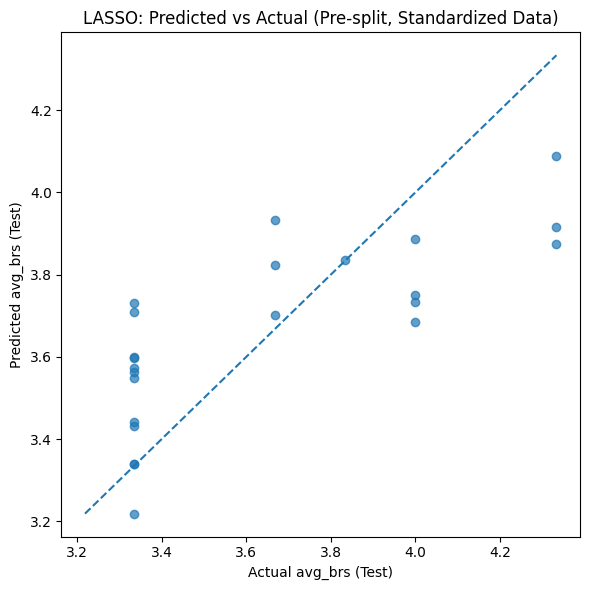

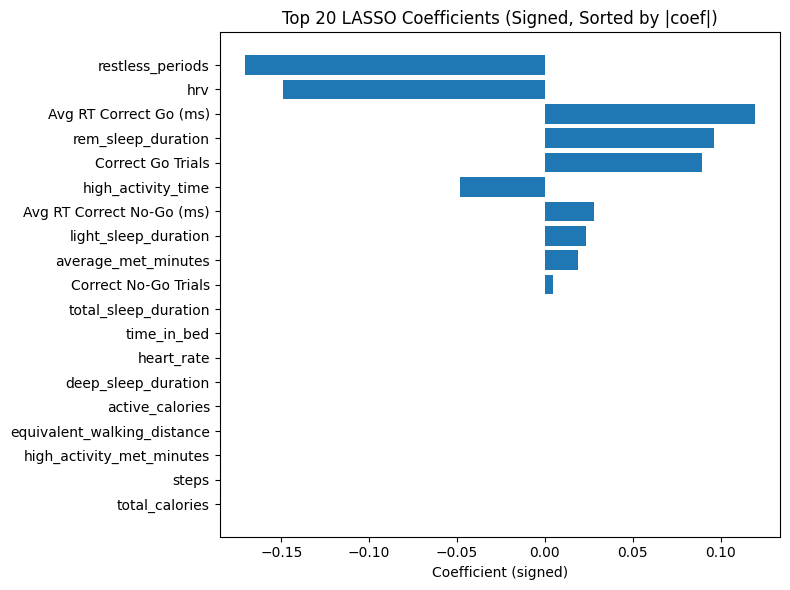

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------------------------
# 0) File paths (edit if needed)
# ---------------------------
PATH_X_TRAIN = "/content/DataByDayXTrain.csv"
PATH_X_TEST  = "/content/DataByDayXTest.csv"
PATH_Y_TRAIN = "/content/DataByDayYTrain.csv"
PATH_Y_TEST  = "/content/DataByDayYTest.csv"

TARGET_COL = "avg_brs"   # update if your y CSV uses a different column name

# ---------------------------
# 1) Load pre-split, standardized data
# ---------------------------
X_train = pd.read_csv(PATH_X_TRAIN)
X_test  = pd.read_csv(PATH_X_TEST)

# In case indices or extra unnamed columns slipped in:
for df_ in (X_train, X_test):
    if "Unnamed: 0" in df_.columns:
        df_.drop(columns=["Unnamed: 0"], inplace=True)

# y may come as a one-column CSV with or without a header; handle both
y_train_raw = pd.read_csv(PATH_Y_TRAIN)
y_test_raw  = pd.read_csv(PATH_Y_TEST)

if TARGET_COL in y_train_raw.columns:
    y_train = y_train_raw[TARGET_COL].to_numpy().ravel()
else:
    # fallback: take the first column
    y_train = y_train_raw.iloc[:, 0].to_numpy().ravel()

if TARGET_COL in y_test_raw.columns:
    y_test = y_test_raw[TARGET_COL].to_numpy().ravel()
else:
    y_test = y_test_raw.iloc[:, 0].to_numpy().ravel()

# Ensure train/test have identical feature sets and ordering
missing_in_test = set(X_train.columns) - set(X_test.columns)
missing_in_train = set(X_test.columns) - set(X_train.columns)
if missing_in_test or missing_in_train:
    raise ValueError(
        f"Feature mismatch.\n"
        f"Missing in X_test: {missing_in_test}\n"
        f"Missing in X_train: {missing_in_train}"
    )
X_test = X_test[X_train.columns]  # align column order

features = X_train.columns.tolist()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ---------------------------
# 2) LASSO with CV (no scaling here; data already standardized)
# ---------------------------
alphas = np.logspace(-3, 2, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
print(f"✅ Best alpha from CV: {best_alpha:.6f}")

# Optionally refit a plain Lasso at the chosen alpha (on the same standardized space)
lasso_final = Lasso(alpha=best_alpha, max_iter=10000)
lasso_final.fit(X_train, y_train)

# ---------------------------
# 3) Evaluate on test data
# ---------------------------
y_pred = lasso_final.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 Test Set Performance:")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# ---------------------------
# 4) Coefficients (SIGNED; no absolute column)
# ---------------------------
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lasso_final.coef_
}).sort_values(by="Coefficient", key=lambda s: np.abs(s), ascending=False)

print("\nTop Features by |Coefficient| (showing SIGNED coefficients):")
print(coef_df.head(15))

# ---------------------------
# 5) Visualization
# ---------------------------
# (a) Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(np.min(y_test), np.min(y_pred)), max(np.max(y_test), np.max(y_pred))]
plt.plot(lims, lims, linestyle='--')  # identity line
plt.xlabel("Actual avg_brs (Test)")
plt.ylabel("Predicted avg_brs (Test)")
plt.title("LASSO: Predicted vs Actual (Pre-split, Standardized Data)")
plt.tight_layout()
plt.show()

# (b) Signed coefficients (sorted by |coef|)
top_k = 20
top_coefs = coef_df.head(top_k).iloc[::-1]  # reverse for nicer barh order
plt.figure(figsize=(8, max(4, top_k * 0.3)))
plt.barh(top_coefs["Feature"], top_coefs["Coefficient"])
plt.xlabel("Coefficient (signed)")
plt.title(f"Top {top_k} LASSO Coefficients (Signed, Sorted by |coef|)")
plt.tight_layout()
plt.show()

# ---------------------------
# 6) (Optional) Save outputs
# ---------------------------
# coef_df.to_csv("lasso_coefficients_signed.csv", index=False)
# pd.DataFrame({
#     "y_test": y_test,
#     "y_pred": y_pred
# }).to_csv("lasso_predictions.csv", index=False)
